In [1]:
!nvidia-smi

Thu Mar 26 14:45:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.07                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   44C    P8              7W /   37W |    2657MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
lr_dir = 'C:/Users/upraj/Prajwal/GSOC/Unsupervised_SR/Task 2/Dataset 6A/Dataset/LR'
hr_dir = 'C:/Users/upraj/Prajwal/GSOC/Unsupervised_SR/Task 2/Dataset 6A/Dataset/HR'

lr_img = np.load(os.path.join(lr_dir + '/sample1.npy'))
hr_img = np.load(os.path.join(hr_dir + '/sample1.npy'))
print(lr_img.shape)
print(hr_img.shape)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

(1, 75, 75)
(1, 150, 150)
Using device: cuda


In [4]:
class Dataset6A(Dataset):
    def __init__(self, lr_dir, hr_dir):
        self.lr_files = sorted([os.path.join(lr_dir, f) for f in os.listdir(lr_dir) if f.endswith('.npy')])
        self.hr_files = sorted([os.path.join(hr_dir, f) for f in os.listdir(hr_dir) if f.endswith('.npy')])

    def __len__(self):
        return len(self.lr_files)

    def __getitem__(self, index):
        lr = np.load(self.lr_files[index]).astype(np.float32)
        hr = np.load(self.hr_files[index]).astype(np.float32)

        # Normalize to [0, 1]
        if lr.max() > 1.0:
            lr = lr / lr.max()
        if hr.max() > 1.0:
            hr = hr / hr.max()

        return torch.tensor(lr), torch.tensor(hr)


dataset = Dataset6A(lr_dir, hr_dir)
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set,  batch_size=32, shuffle=False)

print(f"Train: {train_size} and Test: {test_size}")

Train: 9000 and Test: 1000


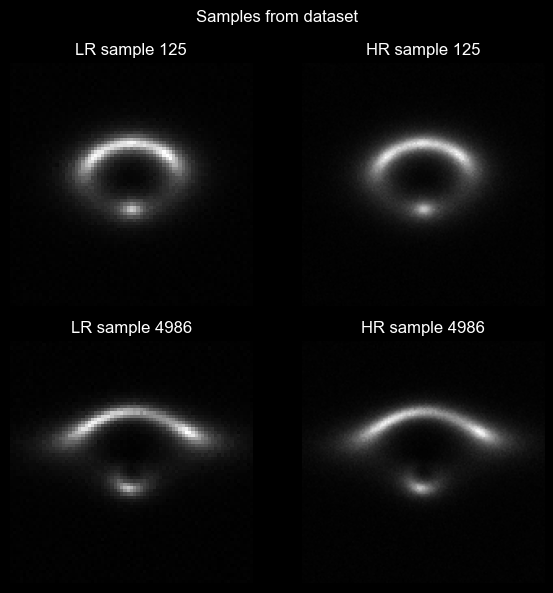

In [5]:
import random
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('Samples from dataset')

indices = random.sample(range(len(dataset)), 2)

for row, index in enumerate(indices):
    lr, hr = dataset[index]
    lr_np = lr.squeeze().numpy()
    hr_np = hr.squeeze().numpy()

    axes[row, 0].imshow(lr_np, cmap='gray')
    axes[row, 0].set_title(f'LR sample {index}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(hr_np, cmap='gray')
    axes[row, 1].set_title(f'HR sample {index}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

### Start with Bilinear interpolation on LR to check how close the result is to HR ground truth

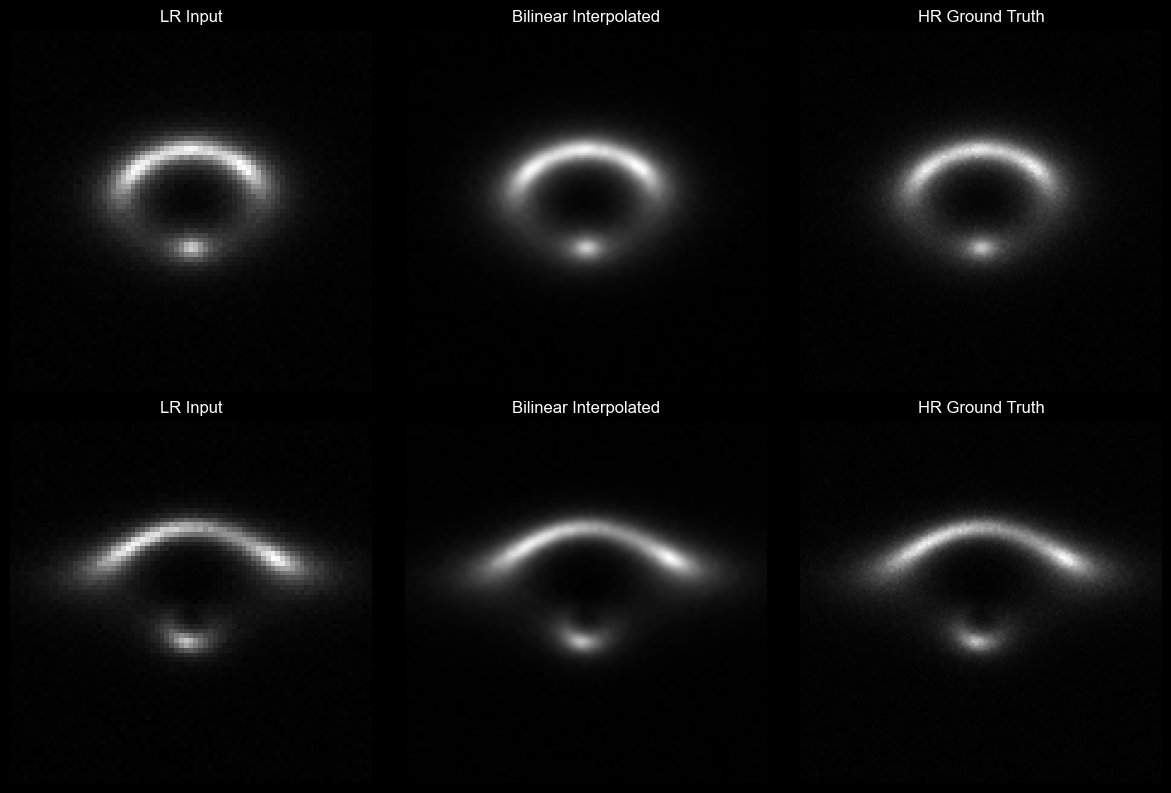

0.0054249777 0.9408854
0.0 1.0


In [6]:
hr_size = 150
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, index in enumerate(indices):
    lr, hr = dataset[index]
    lr_up = F.interpolate(lr.unsqueeze(0), size=(hr_size, hr_size), mode='bilinear', align_corners=False)

    axes[row, 0].imshow(lr.squeeze().numpy(), cmap='gray')
    axes[row, 0].set_title('LR Input')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(lr_up.squeeze().numpy(), cmap='gray')
    axes[row, 1].set_title('Bilinear Interpolated')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(hr.squeeze().numpy(), cmap='gray')
    axes[row, 2].set_title('HR Ground Truth')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()
print(lr_up.squeeze().numpy().min(), lr_up.squeeze().numpy().max())
print(hr.squeeze().numpy().min(), hr.squeeze().numpy().max())

Visually, interpolated LR and HR images look very similar. Since interpolation is working well, we know the signal is smooth and low-frequency dominant.

In [7]:
def compute_metrics(pred, gt):
    mse_val = float(np.mean((gt - pred) ** 2))
    psnr_val = psnr(gt, pred, data_range=1.0)
    ssim_val = ssim(gt, pred, data_range=1.0)
    return mse_val, psnr_val, ssim_val

In [8]:
total_mse = 0
total_psnr = 0
total_ssim = 0
count = 0

for lr_imgs, hr_imgs in DataLoader(dataset, batch_size=64):
    lr_up = F.interpolate(lr_imgs, size=(hr_size, hr_size),mode='bilinear', align_corners=False)

    for pred, gt in zip(lr_up.squeeze().numpy(), hr_imgs.squeeze().numpy()):
        m, p, s = compute_metrics(pred, gt)
        total_mse += m
        total_psnr += p
        total_ssim += s
        count += 1

print("Metrics of Bilinear Interpolation")
print(f"MSE: {total_mse / count:.6f}")
print(f"PSNR: {total_psnr / count:.4f} dB")
print(f"SSIM: {total_ssim / count:.6f}")

Metrics of Bilinear Interpolation
MSE: 0.000069
PSNR: 41.6584 dB
SSIM: 0.975671


The results are strong without any learning. So the gap between LR and HR in the dataset is not large, hence the task is not about recovering
heavily degraded images. We do not need a GAN for this task as it will be an over-kill.
I use EDSR with residual scaling.

I also thought of using RRDB. Since the textures are not complex, RRDB's strength of recovering fine details is lost and might overfit.
EDSR is a better idea with more stability.

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, num_features, res_scale=0.1):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1),
        )
        self.res_scale = res_scale

    def forward(self, x):
        return x + self.body(x) * self.res_scale


class Upsampler(nn.Module):
    def __init__(self, scale_factor, num_features):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_features, num_features * (scale_factor ** 2), kernel_size=3, padding=1),
            nn.PixelShuffle(scale_factor),
        )

    def forward(self, x):
        return self.body(x)


class EDSR(nn.Module):
    def __init__(self, scale_factor=2, num_features=64, num_res_blocks=16, res_scale=0.1, in_channels=1):
        super().__init__()

        self.head = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)

        self.body = nn.Sequential(
            *[ResidualBlock(num_features, res_scale) for _ in range(num_res_blocks)],
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        )

        self.tail = nn.Sequential(
            Upsampler(scale_factor, num_features),
            nn.Conv2d(num_features, in_channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        head_out = self.head(x)
        body_out = self.body(head_out)
        res = head_out + body_out
        out = self.tail(res)
        return out


model = EDSR().to(device)

### Combined Loss for super-resolution
- L1 loss (less sensitive to outliers)
- FFT magnitude loss to preserve frequency energy distribution (light weight)

In [10]:
class SRLoss(nn.Module):
    def __init__(self, fft_weight=0.05):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.fft_weight = fft_weight

    def _fft_loss(self, pred, target):
        pred_fft = torch.fft.fft2(pred.float(), norm='ortho')
        target_fft = torch.fft.fft2(target.float(), norm='ortho')
        return F.l1_loss(torch.abs(pred_fft), torch.abs(target_fft))

    def forward(self, pred, target):
        return self.l1(pred, target) + self.fft_weight * self._fft_loss(pred, target)

In [11]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    total_mse = 0
    total_psnr = 0
    total_ssim = 0
    count = 0
    with torch.no_grad():
        for lr_imgs, hr_imgs in loader:
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)
            preds = model(lr_imgs)
            total_loss += criterion(preds, hr_imgs).item()
            for pred, gt in zip(preds.cpu().numpy(), hr_imgs.cpu().numpy()):
                m, p, s = compute_metrics(pred.squeeze(), gt.squeeze())
                total_mse += m
                total_psnr += p
                total_ssim += s
                count += 1
    return total_loss/len(loader), total_mse/count, total_psnr/count, total_ssim/count

In [12]:
num_epochs = 40
lr_rate = 1e-4

#criterion = nn.MSELoss()
criterion = SRLoss(fft_weight=0.05)
optimizer = optim.Adam(model.parameters(), lr=lr_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

train_losses, test_losses = [], []
test_mses, test_psnrs, test_ssims = [], [], []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    for lr_imgs, hr_imgs in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}"):
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)
        optimizer.zero_grad()
        preds = model(lr_imgs)
        loss  = criterion(preds, hr_imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    t_loss, t_mse, t_psnr, t_ssim = evaluate(model, test_loader)

    train_losses.append(avg_train_loss)
    test_losses.append(t_loss)
    test_mses.append(t_mse)
    test_psnrs.append(t_psnr)
    test_ssims.append(t_ssim)

    print(f"Epoch {epoch} , Train Loss: {avg_train_loss:.4e} , "f"Test Loss: {t_loss:.4e} , MSE: {t_mse:.4e} , "f"PSNR: {t_psnr:.2f} dB , SSIM: {t_ssim:.4f}")

torch.save(model.state_dict(), 'edsr_6a.pth')

Epoch 1/40: 100%|██████████| 282/282 [02:31<00:00,  1.87it/s]


Epoch 1 , Train Loss: 8.2792e-03 , Test Loss: 5.9382e-03 , MSE: 7.1331e-05 , PSNR: 41.50 dB , SSIM: 0.9681


Epoch 2/40: 100%|██████████| 282/282 [02:33<00:00,  1.84it/s]


Epoch 2 , Train Loss: 5.3817e-03 , Test Loss: 5.3124e-03 , MSE: 6.2046e-05 , PSNR: 42.11 dB , SSIM: 0.9760


Epoch 3/40: 100%|██████████| 282/282 [02:31<00:00,  1.86it/s]


...

Epoch 38 , Train Loss: 5.1243e-03 , Test Loss: 5.1250e-03 , MSE: 5.9043e-05 , PSNR: 42.33 dB , SSIM: 0.9776


Epoch 39/40: 100%|██████████| 282/282 [02:25<00:00,  1.93it/s]


Epoch 39 , Train Loss: 5.1253e-03 , Test Loss: 5.1225e-03 , MSE: 5.8926e-05 , PSNR: 42.34 dB , SSIM: 0.9776


Epoch 40/40: 100%|██████████| 282/282 [02:27<00:00,  1.92it/s]


Epoch 40 , Train Loss: 5.1270e-03 , Test Loss: 5.1213e-03 , MSE: 5.8936e-05 , PSNR: 42.33 dB , SSIM: 0.9776


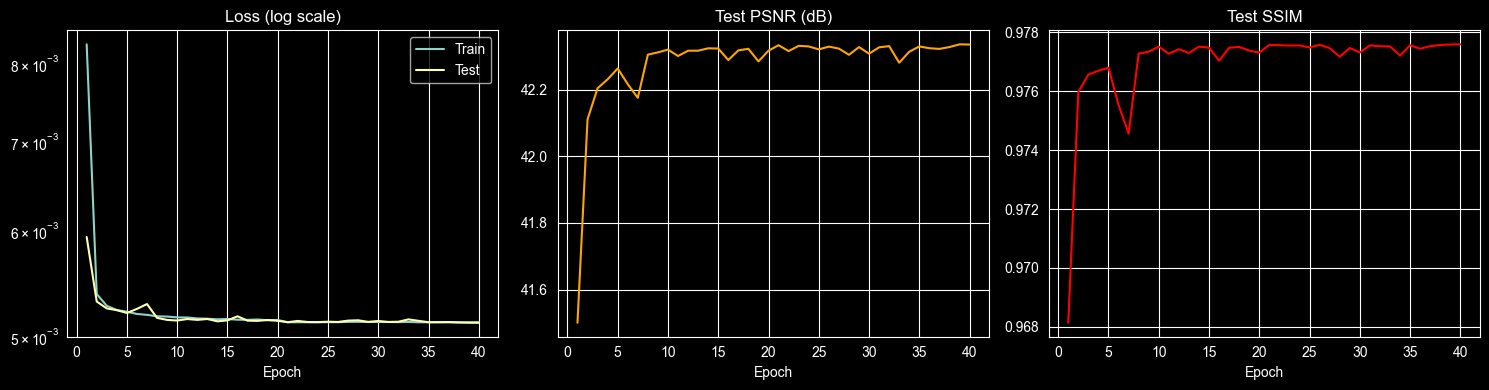

In [13]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, train_losses, label='Train')
axes[0].plot(epochs, test_losses,  label='Test')
axes[0].set_yscale('log')
axes[0].set_title('Loss (log scale)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, test_psnrs, color='orange')
axes[1].set_title('Test PSNR (dB)')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

axes[2].plot(epochs, test_ssims, color='red')
axes[2].set_title('Test SSIM')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [15]:
model.load_state_dict(torch.load('edsr_6a.pth', map_location=device, weights_only=True))
_, edsr_mse, edsr_psnr, edsr_ssim = evaluate(model, test_loader)

print(f"{'Metric':<10} {'Bilinear':>15} {'EDSR':>15}")
print(f"{'MSE':<10} {total_mse/count:>15.6f} {edsr_mse:>15.6f}")
print(f"{'PSNR (dB)':<10} {total_psnr/count:>15.4f} {edsr_psnr:>15.4f}")
print(f"{'SSIM':<10} {total_ssim/count:>15.6f} {edsr_ssim:>15.6f}")

Metric            Bilinear            EDSR
MSE               0.000069        0.000059
PSNR (dB)          41.6584         42.3349
SSIM              0.975671        0.977587


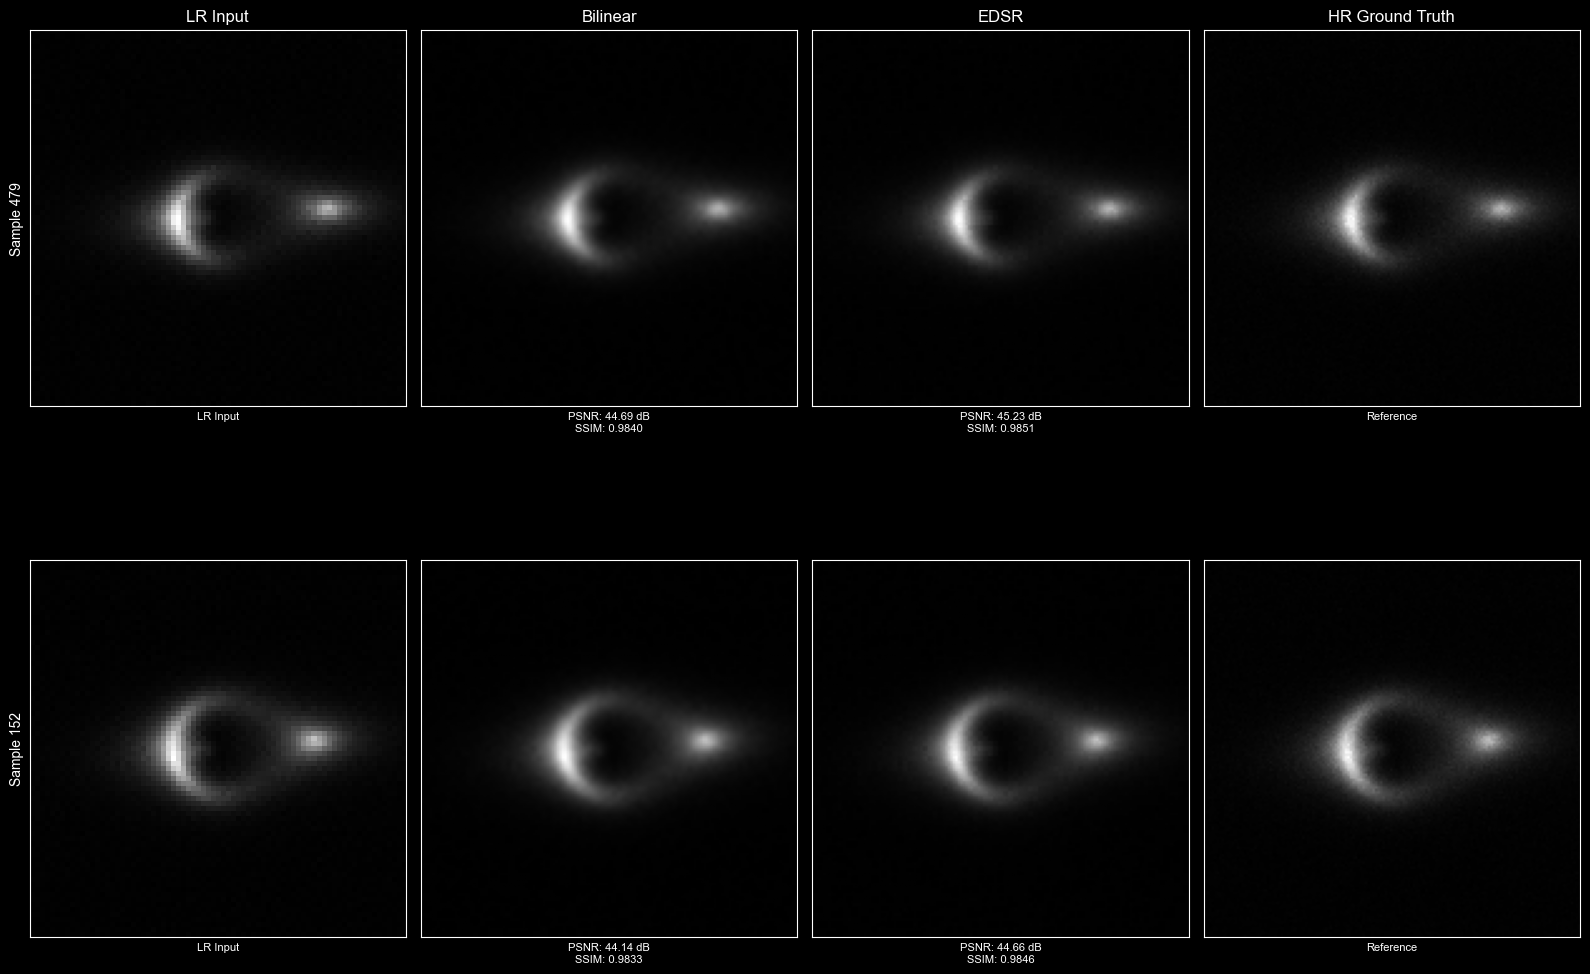

In [16]:
# 2 test samples with highest EDSR PSNR
model.eval()
per_sample_scores = []

for index in range(len(test_set)):
    lr, hr = test_set[index]
    hr_np = hr.squeeze().numpy()
    with torch.no_grad():
        edsr_out = model(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
    _, p, _ = compute_metrics(edsr_out, hr_np)
    per_sample_scores.append((index, p))

top2 = [index for index, _ in sorted(per_sample_scores, key=lambda x: x[1], reverse=True)[:2]]

fig, axes = plt.subplots(2, 4, figsize=(16, 12))

cols = ['LR Input', 'Bilinear', 'EDSR', 'HR Ground Truth']
for col, title in enumerate(cols):
    axes[0, col].set_title(title)

for row, index in enumerate(top2):
    lr, hr = test_set[index]
    hr_np = hr.squeeze().numpy()
    lr_up = F.interpolate(lr.unsqueeze(0), size=(hr_size, hr_size), mode='bilinear', align_corners=False).squeeze()
    with torch.no_grad():
        edsr_out = model(lr.unsqueeze(0).to(device)).squeeze().cpu()

    _, bilinear_psnr, bilinear_ssim = compute_metrics(lr_up.numpy(), hr_np)
    _, edsr_psnr, edsr_ssim = compute_metrics(edsr_out.numpy(), hr_np)

    imgs = [lr.squeeze(), lr_up, edsr_out, hr.squeeze()]
    labels = ['LR Input', f'PSNR: {bilinear_psnr:.2f} dB\nSSIM: {bilinear_ssim:.4f}', f'PSNR: {edsr_psnr:.2f} dB\nSSIM: {edsr_ssim:.4f}', 'Reference']

    for col, (img, label) in enumerate(zip(imgs, labels)):
        axes[row, col].imshow(img.numpy(), cmap='gray')
        axes[row, col].set_xlabel(label, fontsize=8)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    axes[row, 0].set_ylabel(f'Sample {index}', fontsize=10)

plt.tight_layout()
plt.show()

We can see a very small improvement by using a neural network over a simple interpolation.